# Exploratory Data Analysis
* In this notebook, I examine the new plant diseases dataset prior to building a crop disease identification model.
* The goal is to understand the dataset's structure, the number and balance of the classes, and the properties of the images, so that these help inform the design of the data pipeline and model in subsequent phases.
* The dataset is sourced from Kaggle and consists of leaf photographs labeled by crop species and disease condition, including healthy states.
* It provides separate training and validation sets.
* This analysis examines the training set for the data.



In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

print("Path to dataset files:", path)

100%|██████████| 2.70G/2.70G [00:37<00:00, 76.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2


In [ ]:
import os
#Walking through the directories in the data
for root, dirs, files, in os.walk(path):
    depth = root.replace(path, "").count(os.sep)
    if depth < 3:
        indent = "  " * depth
        print(
            f"{indent}{os.path.basename(root)}/ ({len(dirs)} subdirs, {len(files)} files)"
        )
    if depth >= 3:
        dirs[:] = []

2/ (3 subdirs, 0 files)
  test/ (1 subdirs, 0 files)
    test/ (0 subdirs, 33 files)
  New Plant Diseases Dataset(Augmented)/ (1 subdirs, 0 files)
    New Plant Diseases Dataset(Augmented)/ (2 subdirs, 0 files)
  new plant diseases dataset(augmented)/ (1 subdirs, 0 files)
    New Plant Diseases Dataset(Augmented)/ (2 subdirs, 0 files)


In [ ]:
nested_dir = os.path.join(
    path,
    "New Plant Diseases Dataset(Augmented)",
    "New Plant Diseases Dataset(Augmented)"
)

print("Contents of the nested directory:")
for item in sorted(os.listdir(nested_dir)):
    full = os.path.join(nested_dir, item)
    kind = "directory" if os.path.isdir(full) else "file"
    print(f"  {item}  ({kind})")

Contents of the nested directory:
  train  (directory)
  valid  (directory)


In [ ]:
train_dir = os.path.join(
    path,
    "New Plant Diseases Dataset(Augmented)",
    "New Plant Diseases Dataset(Augmented)",
    "train"
)

print("Training directory exists:", os.path.isdir(train_dir))

if os.path.isdir(train_dir):
    entries = sorted(os.listdir(train_dir))
    class_dirs = [
        e for e in entries if os.path.isdir(os.path.join(train_dir, e))
    ]
    print("Number of class subdirectories:", len(class_dirs))
    print("First few class names:")
    for name in class_dirs[:5]:
        print("  ", name)

Training directory exists: True
Number of class subdirectories: 38
First few class names:
   Apple___Apple_scab
   Apple___Black_rot
   Apple___Cedar_apple_rust
   Apple___healthy
   Blueberry___healthy


# Classes
* The training data consists of 38 different classes, each of which corresponds with a combination of a disease (or no disease) and a plant species
* Several different species appear, each with multiple disease conditions and a healthy condition
* The number of classes will determine the size of the model output layer in later phases

In [ ]:
#Enumerating through the different classes

class_names = sorted(os.listdir(train_dir))

class_names = [
    c for c in class_names if os.path.isdir(os.path.join(train_dir, c))
]

print(f"Number of classes: {len(class_names)}")

for name in class_names:
    print(name)

Number of classes: 38
Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___Powdery_mildew
Cherry_(including_sour)___healthy
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___Northern_Leaf_Blight
Corn_(maize)___healthy
Grape___Black_rot
Grape___Esca_(Black_Measles)
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Grape___healthy
Orange___Haunglongbing_(Citrus_greening)
Peach___Bacterial_spot
Peach___healthy
Pepper,_bell___Bacterial_spot
Pepper,_bell___healthy
Potato___Early_blight
Potato___Late_blight
Potato___healthy
Raspberry___healthy
Soybean___healthy
Squash___Powdery_mildew
Strawberry___Leaf_scorch
Strawberry___healthy
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Target_Spot
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Tomato_mosaic_virus
Tomato___he

# Class Distribution
The training set contains a total of 70,295 images. The largest class holds 2,022 images, while the smallest holds 1,642 images. This gives it a largest to smallest ratio of about 1.23. Since the dataset is approximately balanced, I will not need to do any accounting for that during training, and the overall accuracy will be a reasonable primary metric.

In [ ]:
class_counts = {}

for name in class_names:
    class_dir = os.path.join(train_dir, name)
    num_images = len(os.listdir(class_dir))
    class_counts[name] = num_images

sorted_counts = sorted(
    class_counts.items(),
    key = lambda item: item[1],
    reverse = True
)

for name, count in sorted_counts:
    print(f"{count:5d}  {name}")

counts_only = list(class_counts.values())
total = sum(counts_only)

print(f"Total Images: {total}")
print(f"Number of Classes: {len(counts_only)}")
print(f"Largest Class: {max(counts_only)}")
print(f"Smallest Class: {min(counts_only)}")
print(f"Mean per Class: {total / len(counts_only):.1f}")
print(f"Ratio largest:smallest:: {max(counts_only) / min(counts_only):.2f}")

 2022  Soybean___healthy
 2016  Apple___Apple_scab
 2010  Orange___Haunglongbing_(Citrus_greening)
 2008  Apple___healthy
 1988  Pepper,_bell___healthy
 1987  Apple___Black_rot
 1961  Tomato___Tomato_Yellow_Leaf_Curl_Virus
 1939  Potato___Early_blight
 1939  Potato___Late_blight
 1926  Tomato___healthy
 1920  Grape___Esca_(Black_Measles)
 1920  Tomato___Early_blight
 1913  Pepper,_bell___Bacterial_spot
 1908  Corn_(maize)___Northern_Leaf_Blight
 1907  Corn_(maize)___Common_rust_
 1888  Grape___Black_rot
 1882  Tomato___Leaf_Mold
 1859  Corn_(maize)___healthy
 1851  Tomato___Late_blight
 1838  Peach___Bacterial_spot
 1827  Tomato___Target_Spot
 1826  Cherry_(including_sour)___healthy
 1824  Potato___healthy
 1824  Strawberry___healthy
 1816  Blueberry___healthy
 1790  Tomato___Tomato_mosaic_virus
 1781  Raspberry___healthy
 1774  Strawberry___Leaf_scorch
 1760  Apple___Cedar_apple_rust
 1745  Tomato___Septoria_leaf_spot
 1741  Tomato___Spider_mites Two-spotted_spider_mite
 1736  Squash_

# Distribution bar chart
The Bar Chart above shows the image count for each class in the dataset. Most of the bars are of similar length, indicating that the dataset is reasonably well balanced.

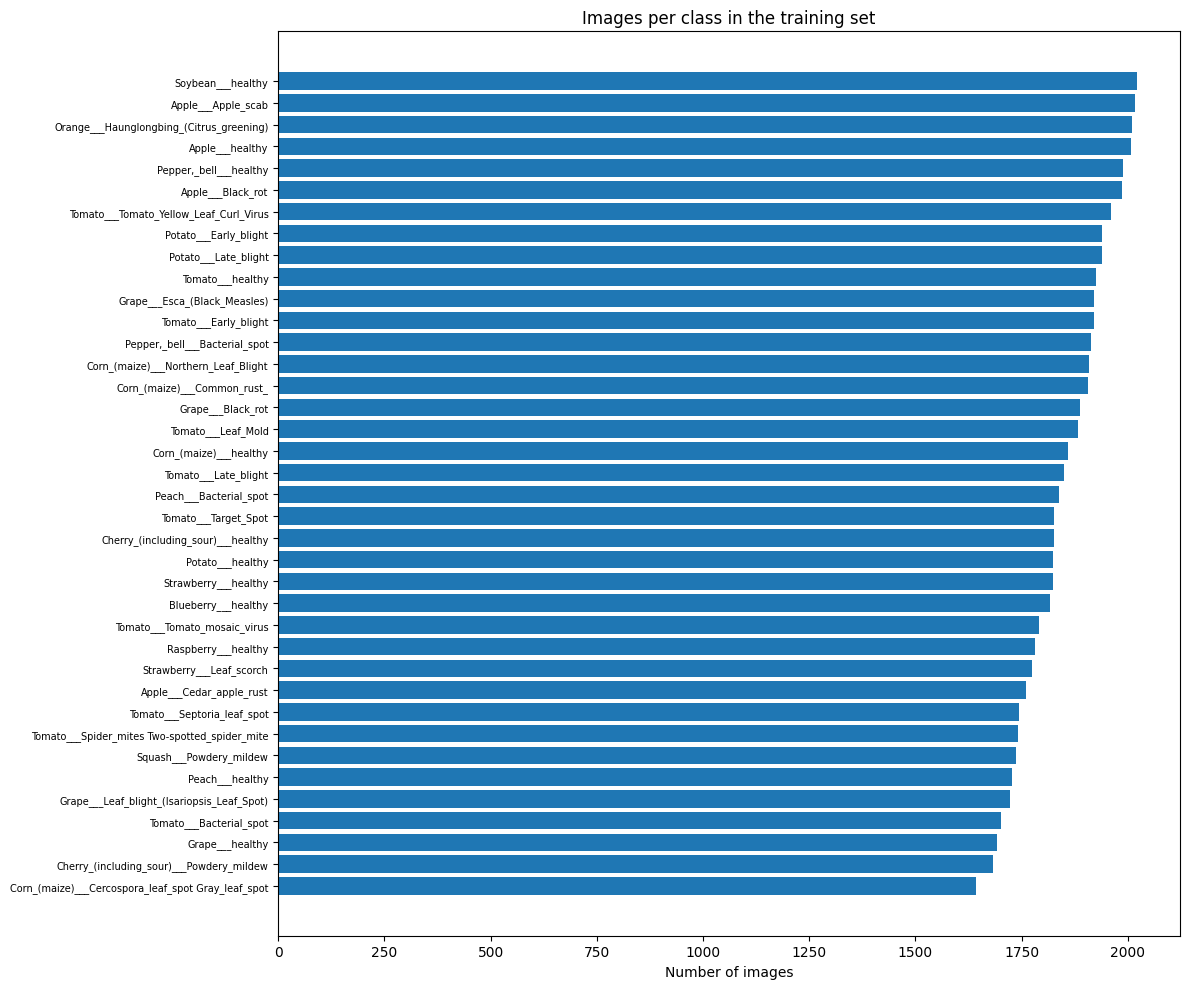

In [ ]:
import matplotlib.pyplot as plt
names = [item[0] for item in sorted_counts]
values = [item[1] for item in sorted_counts]

#set the size of the figure
plt.figure(figsize=(12, 10))
#create different bars for the different categories
plt.barh(range(len(names)), values)
#Y axis labels
plt.yticks(range(len(names)), names, fontsize=7)
#X axis label
plt.xlabel("Number of images")
#Title
plt.title("Images per class in the training set")
plt.gca().invert_yaxis() #place the highest values at the top
plt.tight_layout() #fits everything properly
plt.show() #show the image

# Image Samples
* The sample images confirm that each class contains photographs of plant leaves exhibiting different conditions.
* The images are presented mostly with the same background, and the leaf occupies most, or sometimes all of the frame.

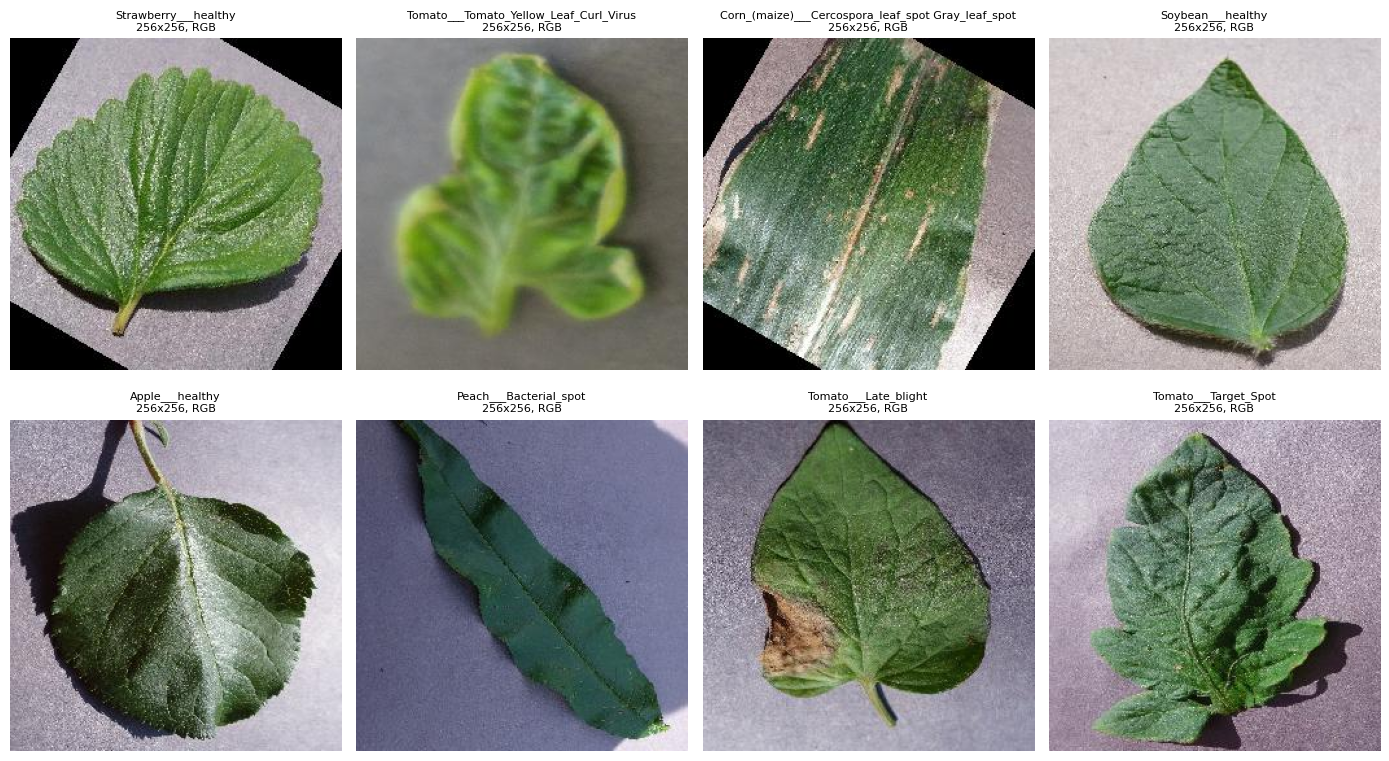

In [ ]:
from PIL import Image
import random

NCTS = 8

sampled_classes = random.sample(
    class_names,
    min(NCTS, len(class_names))
)

plt.figure(figsize=(14, 8))

for i, name in enumerate(sampled_classes):
    class_dir = os.path.join(train_dir, name)
    image_file = random.choice(os.listdir(class_dir))
    image_path = os.path.join(class_dir, image_file)
    img = Image.open(image_path)
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(
        f"{name}\n{img.size[0]}x{img.size[1]}, {img.mode}",
        fontsize=8
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

All sampled images have dimensions of 256x256 pixels and are in RGB color mode.

In [ ]:
dimensions = []
for name in random.sample(class_names, min(10, len(class_names))):
    class_dir = os.path.join(train_dir, name)
    for image_file in random.sample(
        os.listdir(class_dir),
        min(20, len(os.listdir(class_dir)))
    ):
        image_path = os.path.join(class_dir, image_file)
        with Image.open(image_path) as img:
            dimensions.append(img.size)

unique_dimensions = set(dimensions)
print(f"Sampled {len(dimensions)} images.")
print(f"Unique dimensions found: {unique_dimensions}")

Sampled 200 images.
Unique dimensions found: {(256, 256)}


#Data Integrity
No Corrupted or Unreadable files were found. A total of 570 files were analyzed, and the dominant format overwhelmingly was JPEG.

In [ ]:
from PIL import Image
from collections import Counter
import random

formats = Counter() #counts the number of appearances for each format
corrupted_files = [] #list of corrupted files
sample_per_class = 15 #sample 15 images per class

for name in class_names:
    class_dir = os.path.join(train_dir, name) #get the class directory
    files = os.listdir(class_dir) #get the files inside each class directory
    sample = random.sample(files, min(sample_per_class, len(files))) #get a random sample of the files inside each class directory
    for image_file in sample:
        image_path = os.path.join(class_dir, image_file) #get the image directory
        try:
            with Image.open(image_path) as img:
                img.verify()
                formats[img.format] += 1 #count each new format
        except Exception as e:
            corrupted_files.append((image_path, str(e)))

total_checked = sum(formats.values()) + len(corrupted_files)
print(f"Images checked sample size: {total_checked}")
print(f"Corrupted/unreadable files: {len(corrupted_files)}")
print(f"File formats present: {dict(formats)}")

Images checked sample size: 570
Corrupted/unreadable files: 0
File formats present: {'JPEG': 570}
